# 01 — Reproduction: Mukiibi & Mikelson (2026)

This notebook implements the full analysis published in:

> Mukiibi, R. & Mikelson, J. (2026). *A Machine Learning Approach for GHI
> Bias Correction: Validation of Random Forest Performance Across
> Sub-Saharan Africa.* IEEE.

Run the cells in order. Tables III and IV are printed in the output cells
of §4 and §6.4 respectively.

## Pipeline overview

| Step | Library object | What it does |
|---|---|---|
| Data assembly | `FeatureService.build_training_pairs` | Joins ground GHI with NASA POWER + CAMS satellite features |
| Station selection | `auxscripts.pick_training_and_holdout_stations` | Selects 24 stations by coverage; holds out Kampala and Wadelai as the paper's spatial test fold |
| Cleaning + features | `FeatureSpec` + `Preprocessor` | Paper §II.A curation rules and 33 derived and pass-through predictors (§1, §3) |
| Train | `Trainer` + `RandomForestParams` | 200-tree RF with `min_samples_leaf=5`; reports Table III on the held-out stations |
| Save | `TrainedBundle` (auto) | Self-contained directory the portal loads |
| Validate | `auxscripts.build_katongole_inference_frame` + `auxscripts.score_table_iv` | Reproduces paper Table IV against the Katongole 2017–2022 climatology |

### Inputs, outputs, prerequisites

| | |
|---|---|
| **Warehouse inputs** | `ground_measurements` (24 stations), `nasa_daily_vars_long`, `cams_daily_vars_long`, `irradiance_daily` |
| **Local input** | `data/external_references/katongole_2023_monthly.csv` (54 sites × 12 months, 2017–2022 climatology) |
| **Output bundle** | `data/bundles/mukiibi_mikelson_2026/` — what the portal loads |
| **Optional output** | If `LOG_TO_WANDB=True`, a W&B run + artifact |
| **GCP access** | You must be granted access to the `solar-irradiation-estimation` GCP project before running this notebook. Contact the project owner to be added. Once added, authenticate via `gcloud auth application-default login` (local) or the bootstrap cell below (Colab). |
| **Wall time** | ~5 min on a workstation |

In [1]:
import shutil
import shlex
import sys
import os

PROJECT_ID = "solar-irradiation-estimation"

if "google.colab" in sys.modules:
    # --- GOOGLE COLAB AUTOMATED SETUP ---
    REPO = "Marconi-Lab/Solar_irradiation"
    BRANCH = "jm/add_model"

    if not os.path.exists("/content/Solar_irradiation/.git"):
        try:
            from google.colab import userdata
            token = userdata.get("GITHUB_PAT")
            clone_url = f"https://{token}@github.com/{REPO}.git"
            print("Cloning with Colab secret 'GITHUB_PAT'.")
        except Exception:
            clone_url = f"git@github.com:{REPO}.git"
            print(
                "Colab secret 'GITHUB_PAT' not set — trying SSH. If the "
                "clone fails, add a PAT under Tools → Secrets and re-run."
            )
        !git clone -q -b {BRANCH} {clone_url} /content/Solar_irradiation

    %cd /content/Solar_irradiation
    !pip install -q -e . 2>&1 | tail -3

    from google.colab import auth
    auth.authenticate_user()
    !gcloud config set project {PROJECT_ID} 2>/dev/null
    print("Colab setup complete.")

else:
    # --- LOCAL WSL / LINUX AUTOMATED SETUP ---
    print("Running in Local Linux/WSL Environment.")
    os.environ["GOOGLE_CLOUD_PROJECT"] = PROJECT_ID

    # 1. Look for gcloud
    gcloud_path = shutil.which("gcloud")

    # Fallback check
    if not gcloud_path:
        home_bin = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
        if os.path.exists(home_bin):
            gcloud_path = home_bin

    # 2. Install if not found
    if not gcloud_path:
        print("SDK not found anywhere on the system. Installing now...")
        get_ipython().system(
            "curl -sSL https://sdk.cloud.google.com | bash -s -- "
            "--disable-prompts > /dev/null"
        )
        gcloud_path = os.path.expanduser("~/google-cloud-sdk/bin/gcloud")
    else:
        print(f"gcloud detected successfully at: {gcloud_path}")

    safe_gcloud_path = shlex.quote(gcloud_path)

    # 3. Authenticate
    print("\nOpening your system browser for Google Cloud verification...")
    get_ipython().system(f"{safe_gcloud_path} auth application-default login")

    # 4. Set project
    get_ipython().system(f"{safe_gcloud_path} config set project {PROJECT_ID} 2>/dev/null")
    print(f"\nLocal setup complete! Active project set to: {PROJECT_ID}")

Running in Local Linux/WSL Environment.
gcloud detected successfully at: /mnt/c/Program Files (x86)/Google/Cloud SDK/google-cloud-sdk/bin/gcloud

Opening your system browser for Google Cloud verification...
Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=X5PAEr0L5bi4qrdigWfTh3ELw2DeRE&access_type=offline&code_challenge=oteNyPhhb30fWeL1yfqnNdePj7-CJb_w0Need35H4fo&code_challenge_method=S256

gio: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.goo

## 0 — Setup

In [2]:
%load_ext autoreload
%autoreload 2

import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash

# Locate project root by walking up until we see src/susse/. Works both
# locally (notebook cwd is the notebook's folder) and in Colab (after the
# bootstrap cell cd's into /content/Solar_irradiation).
_HERE = Path.cwd().resolve()
_PROJECT_ROOT = _HERE
while _PROJECT_ROOT != _PROJECT_ROOT.parent and not (_PROJECT_ROOT / "src" / "susse").exists():
    _PROJECT_ROOT = _PROJECT_ROOT.parent
_NB_DIR = _PROJECT_ROOT / "notebooks" / "papers" / "mukiibi_mikelson_2026"
sys.path.insert(0, str(_PROJECT_ROOT / "src"))
sys.path.insert(0, str(_NB_DIR))

# Companion helpers — see auxscripts.py for the implementations.
import auxscripts

print(f"project root: {_PROJECT_ROOT}")

project root: /home/mukiibi/Github/SolarIrradiation


In [3]:
# ----- Top-level configuration -----
# Paper-faithful parameters (paper §III). Edit here if you want to
# experiment; all downstream cells read from these constants.

# W&B run/artifact tracking. Defaults to OFF. The first run with logging
# on auto-creates the project under your default W&B entity; flip the
# project to Public via Project settings → Privacy to share the link.
WANDB_PROJECT = "susse-mukiibi-mikelson-2026"
WANDB_ENTITY = None
LOG_TO_WANDB = False
WANDB_TAGS = ("paper-reproduction", "random-forest")

# Paper-faithful Random Forest hyperparameters (paper §III).
RF_N_ESTIMATORS = 200
RF_MIN_SAMPLES_LEAF = 5
RF_MAX_FEATURES = 0.5
RF_RANDOM_STATE = 42

# Set to True to run GridSearchCV / RandomizedSearchCV for all models.
# False (default) skips the search and uses the paper's known best
# hyperparameters directly — much faster for reproducing results.
RUN_GRID_SEARCH = False

# =============================================================================
# Best Hyperparameters (Used as defaults if RUN_GRID_SEARCH=False)
# =============================================================================
# Random Forest
RF_N_ESTIMATORS = 300
RF_MIN_SAMPLES_LEAF = 2
RF_MAX_FEATURES = 0.5
RF_MAX_DEPTH = None

# XGBoost
XGB_N_ESTIMATORS = 200
XGB_LEARNING_RATE = 0.1
XGB_MAX_DEPTH = 6
XGB_SUBSAMPLE = 1.0
XGB_COLSAMPLE_BYTREE = 1.0

# SVR
SVR_C = 10.0
SVR_EPSILON = 0.1
SVR_KERNEL = "rbf"

# Ridge
RIDGE_ALPHA = 0.01

# Global
RANDOM_STATE = 42


# Paper-faithful station selection: 22 training + 2 spatial holdout
# (Kampala = Site A, Wadelai = Site B — paper Table III).
N_TRAINING_STATIONS = 24
N_HOLDOUT_STATIONS = 2
HOLDOUT_STATIONS = ["wadelai", "kampala"]

# Validation window for the Katongole §6 comparison. Matches the
# 2015–2022 period of the Katongole et al. dataset.
VALIDATION_START_YEAR = 2017
VALIDATION_END_YEAR = 2022

BUNDLES_ROOT = (_PROJECT_ROOT / "data" / "bundles").resolve()
BUNDLE_DEST = BUNDLES_ROOT / "mukiibi_mikelson_2026"
KATONGOLE_CSV = (
    _PROJECT_ROOT / "data" / "external_references" / "katongole_2023_monthly.csv"
)
assert KATONGOLE_CSV.exists(), f"Missing reference data at {KATONGOLE_CSV}"
print(f"Bundle dest: {BUNDLE_DEST}")
print(f"Validation window: {VALIDATION_START_YEAR}-{VALIDATION_END_YEAR}")

Bundle dest: /home/mukiibi/Github/SolarIrradiation/data/bundles/mukiibi_mikelson_2026
Validation window: 2017-2022


## 1 — Paper-faithful feature selection

Paper Table II lists 33 predictors. They split into four groups:

| Group | Source table | Field on `FeatureSelection` |
|---|---|---|
| NASA POWER auxiliary (20 of 33) | `nasa_daily_vars_long` | `nasa_variable_ids` |
| CAMS clear-sky auxiliary (3 of 33) | `cams_daily_vars_long` | `cams_variable_ids` |
| All-sky irradiance, 2 sources × 3 bands (6 of 33) | `irradiance_daily` (wide) | `include_satellite_irradiance` + `include_satellite_bands` |
| Derived features (CAMS attenuation ratio, day-of-year sin+cos, altitude) | computed | `derived_features` (§3) |

The catalog of available variables is `dim_variable`; `FeatureSelection`
validates each requested ID against it at construction. To browse the
catalog interactively see Notebook 02 (`tutorial/02_query_the_warehouse.ipynb`)
or read `VariableCatalog` in `src/susse/warehouse_ops/population/dim_variable.py`.

In [4]:
from susse.datasets import FeatureSelection
from susse.warehouse_ops.population.types import IrradianceBand, Source

# 20 NASA POWER auxiliary predictors (paper Table II).
# EVLAND and EVPTRNS are excluded — they return NaN at oceanic stations
# in the Gulf of Guinea. `day_of_year` is excluded in favour of the
# sin/cos cyclical encoding computed in §3.
NASA_AUX_VARIABLE_IDS: tuple[str, ...] = (
    "longwave_downward_irr",  "aod_550_adj",          "cloud_amount",
    "precipitable_water",     "airmass",              "zero_plane_displacement",
    "surface_albedo",         "clearness_index",      "temperature",
    "relative_humidity",      "surface_pressure",     "wind_speed",
    "temperature_range",      "precipitation_corrected", "surface_roughness",
    "northern_wind",          "planetary_boundary",   "total_column_ozone",
    "surface_air_density",    "surface_soil_wetness",
)
CAMS_VARIABLE_IDS: tuple[str, ...] = ("ghi_clear", "dhi_clear", "dni_clear")

selection = FeatureSelection(
    nasa_variable_ids=NASA_AUX_VARIABLE_IDS,
    cams_variable_ids=CAMS_VARIABLE_IDS,
    include_satellite_irradiance=(Source.NASA_POWER, Source.CAMS),
    include_satellite_bands=(
        IrradianceBand.GHI, IrradianceBand.DHI, IrradianceBand.DNI,
    ),
    qc_levels=("pass",),
)
print(
    f"Selection: {len(NASA_AUX_VARIABLE_IDS)} NASA aux + "
    f"{len(CAMS_VARIABLE_IDS)} CAMS aux + "
    f"{len(selection.include_satellite_irradiance) * len(selection.include_satellite_bands)} "
    f"satellite irradiance columns"
)

Selection: 20 NASA aux + 3 CAMS aux + 6 satellite irradiance columns


## 2 — Build the training dataset from the warehouse

`FeatureService` joins ground GHI with the satellite features at each
station's geohash5 cell. The station-selection call below uses the
paper's explicit holdout pair (Kampala and Wadelai) and selects the 22
remaining stations with the best data coverage as the training set.

In [5]:
from susse.warehouse_ops.io import BigQueryClient, WarehouseConfig
from susse.warehouse_ops.io.config import TableRefs
from susse.datasets import FeatureService, DatasetManifest, TrainingDataset
from susse.provenance import git_sha, susse_version

bq = BigQueryClient(config=WarehouseConfig())
tables = TableRefs(config=bq.config)
service = FeatureService(bq=bq)

station_meta = bq.query(f"""
    SELECT location,
           ANY_VALUE(lat) AS lat,
           ANY_VALUE(lon) AS lon,
           MIN(date) AS min_date,
           MAX(date) AS max_date,
           COUNT(*)  AS n_rows
    FROM `{tables.ground_measurements}`
    WHERE qc_level = "pass"
    GROUP BY location
    ORDER BY n_rows DESC
""")
TRAINING_STATIONS, HOLDOUT_STATIONS = auxscripts.pick_training_and_holdout_stations(
    station_meta,
    n_training=N_TRAINING_STATIONS,
    n_holdout=N_HOLDOUT_STATIONS,
    holdout_stations=("kampala", "wadelai"),
)
selected_stations = TRAINING_STATIONS + HOLDOUT_STATIONS
print(f"Training stations ({len(TRAINING_STATIONS)}): {TRAINING_STATIONS}")
print(f"Spatial-holdout pair: {HOLDOUT_STATIONS}")

Training stations (22): ('kenya_location3', 'lira', 'ghana_location1', 'nigeria_location1', 'kenya_location5', 'tororo', 'ghana_location3', 'ghana_location2', 'kenya_location2', 'kenya_location6', 'kenya_location4', 'soroti', 'kenya_location13', 'kenya_location8', 'kenya_location10', 'nigeria_location2', 'madagascar_location1', 'kenya_location7', 'kenya_location11', 'egypt_location1', 'madagascar_location2', 'kenya_location14')
Spatial-holdout pair: ('kampala', 'wadelai')


In [6]:
# Pull ground + satellite features for the 24 selected stations across
# their full ground-data range. Cleaners in §3 then filter rows.
DATE_START = station_meta.loc[
    station_meta["location"].isin(selected_stations), "min_date"
].min()
DATE_END = station_meta.loc[
    station_meta["location"].isin(selected_stations), "max_date"
].max()
raw_df = service.build_training_pairs(
    selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    locations=selected_stations,
)
manifest = DatasetManifest(
    name="mukiibi_mikelson_2026_train",
    version="recomputation_v1",
    created_at_utc=pd.Timestamp.now(tz="UTC").isoformat(),
    susse_version=susse_version(),
    git_sha=git_sha(),
    feature_selection=selection,
    date_start=DATE_START,
    date_end=DATE_END,
    location_filter=None,
    warehouse_project=bq.config.project_id,
    warehouse_dataset=bq.config.dataset,
    warehouse_table_mods=service.warehouse_table_mods(selection),
    n_rows=len(raw_df),
    n_cols=len(raw_df.columns),
    column_names=tuple(raw_df.columns),
    content_hash="recomputation",
)
dataset = TrainingDataset(df=raw_df, manifest=manifest)
print(f"Raw training pairs: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
print(f"Date span: {DATE_START} .. {DATE_END}")
print(f"Stations: {raw_df['location'].nunique()}")

Raw training pairs: 24,233 rows × 36 columns
Date span: 2011-03-08 .. 2024-11-25
Stations: 24


## 3 — Configure preprocessing

`FeatureSpec` declares everything that turns the raw warehouse frame
into a model-ready ``(X, y)`` pair.

* **Target** — absolute GHI (`y_ghi_kwh_m2_day`), matching the paper.
* **Cleaners** — three target-quality filters from paper §II.A:
  `GhiUpperBoundCleaner(threshold=12.0)` drops physically-implausible
  values, `IqrLowerBoundCleaner` is a Tukey lower fence,
  `HighMissingYearExcluder(missing_fraction_threshold=0.05)` drops
  sparse (station, year) groups.
* **Pass-through features** — every aux variable from §1 + six
  satellite-irradiance columns produced by `FeatureService`.
* **Derived features**:

  | Feature | Class | Carries |
  |---|---|---|
  | `kt_cams` | `ClearSkyIndexFeature` | CAMS clear-sky attenuation ratio = `cams_ghi_clear / sat_ghi_cams` |
  | `doy_sin`, `doy_cos` | `CyclicalDayOfYearFeature` | Cyclical day-of-year encoding (no wrap-around discontinuity) |
  | `altitude_m` | `AltitudeFeature` (pvlib lookup) | Station elevation |

In [7]:
from susse.preprocessing import (
    AltitudeFeature, ClearSkyIndexFeature, CyclicalDayOfYearFeature,
    FeatureSpec, GhiUpperBoundCleaner, HighMissingYearExcluder,
    IqrLowerBoundCleaner, Preprocessor, PvlibElevationProvider,
)

feature_columns = (
    *(f"nasa_{v}" for v in NASA_AUX_VARIABLE_IDS),
    *(f"cams_{v}" for v in CAMS_VARIABLE_IDS),
    *(
        f"sat_{band.value}_{source.value.lower()}_kwh_m2_day"
        for band in selection.include_satellite_bands
        for source in selection.include_satellite_irradiance
    ),
)
spec = FeatureSpec(
    target_column="y_ghi_kwh_m2_day",
    feature_columns=feature_columns,
    cleaners=(
        GhiUpperBoundCleaner(column="y_ghi_kwh_m2_day", threshold=12.0),
        IqrLowerBoundCleaner(column="y_ghi_kwh_m2_day", multiplier=1.5),
        HighMissingYearExcluder(missing_fraction_threshold=0.05),
    ),
    derived_features=(
        ClearSkyIndexFeature(
            ghi_column="sat_ghi_cams_kwh_m2_day",
            ghi_clear_column="cams_ghi_clear",
            output_column="kt_cams",
        ),
        CyclicalDayOfYearFeature(),
        AltitudeFeature(provider=PvlibElevationProvider()),
    ),
    id_columns=("date", "location", "geohash5", "lat", "lon"),
)
processed = Preprocessor(spec).apply(dataset)
print(
    f"Processed: {processed.n_rows:,} rows × {processed.n_features} features  "
    f"({processed.df['location'].nunique()} stations)"
)

Processed: 16,843 rows × 33 features  (23 stations)


### Data exploration

Four quick views of the training data: target distribution per station,
satellite-vs-observed scatter, feature-correlation heatmap, and a PCA
scatter coloured by station. All four are plot-only — implementations
live in `auxscripts`.

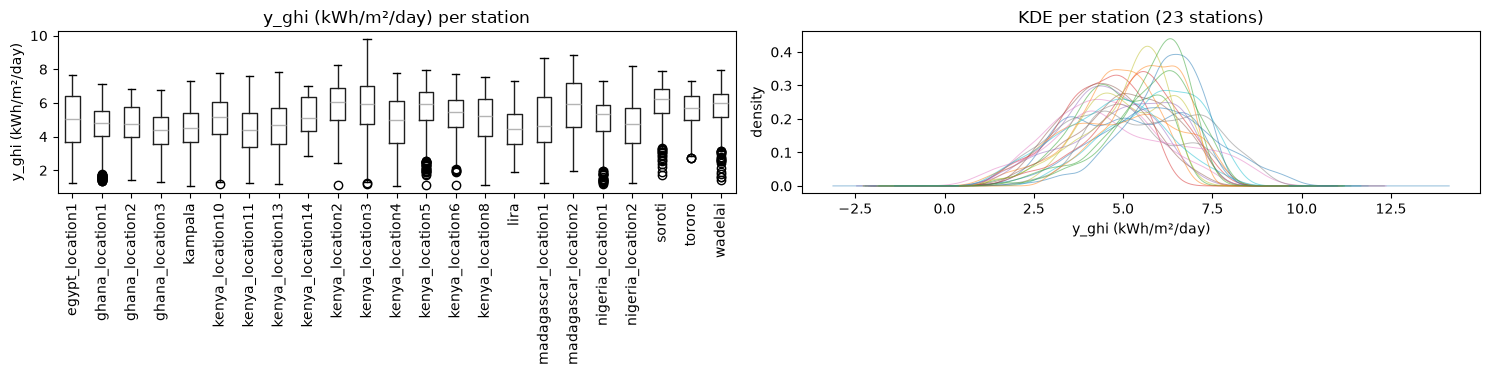

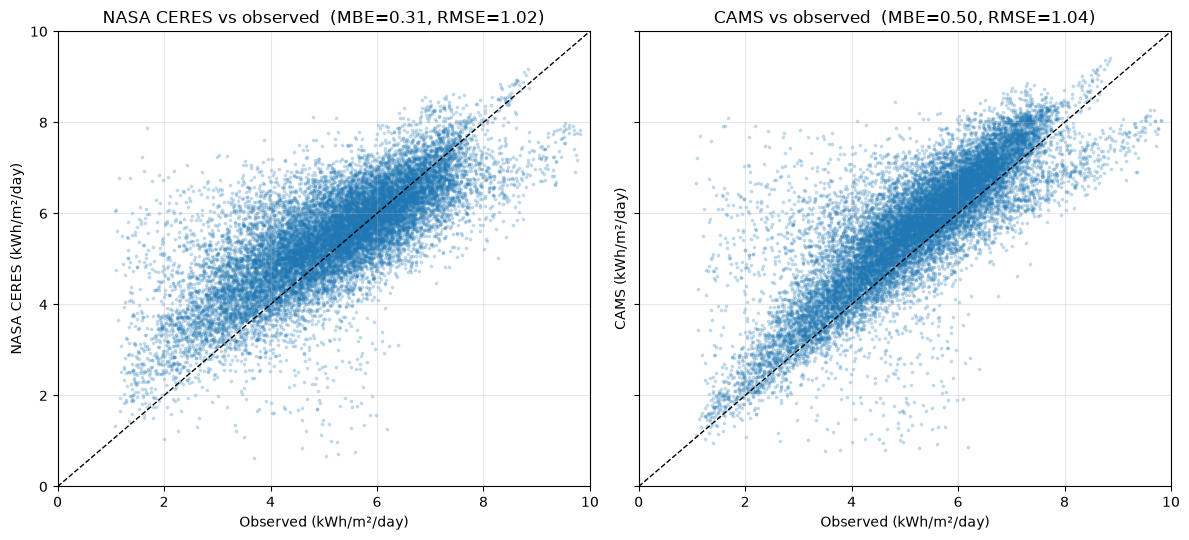

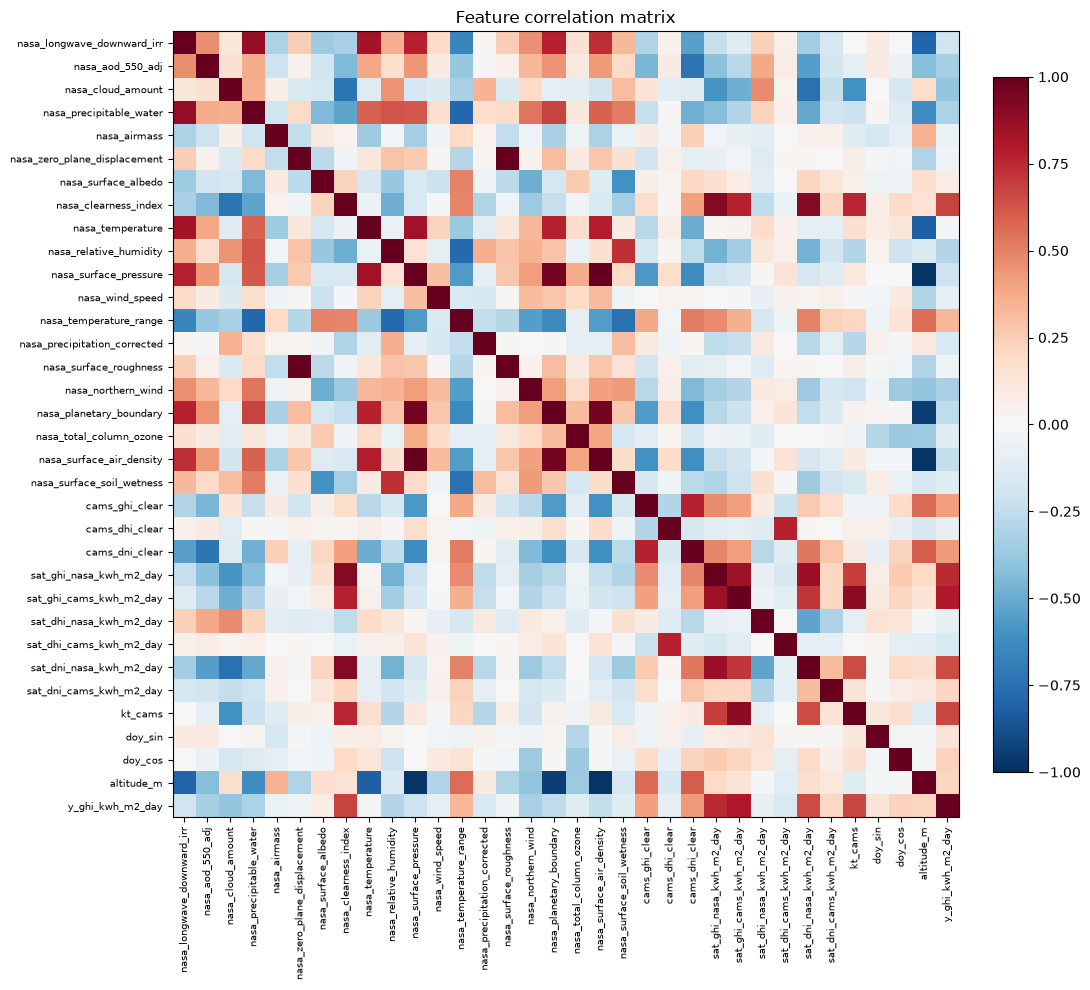

Top 10 features by |correlation| with y_ghi_kwh_m2_day:
sat_ghi_cams_kwh_m2_day    0.802
sat_ghi_nasa_kwh_m2_day    0.749
nasa_clearness_index       0.674
kt_cams                    0.669
sat_dni_nasa_kwh_m2_day    0.649
cams_dni_clear             0.424
cams_ghi_clear             0.412
nasa_cloud_amount          0.389
nasa_temperature_range     0.334
nasa_aod_550_adj           0.333


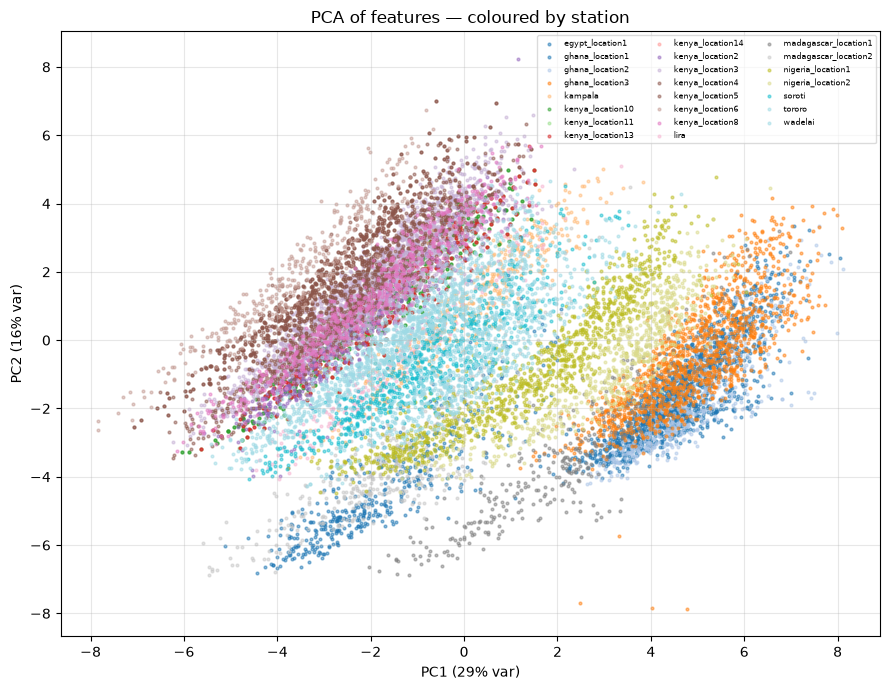

In [8]:
from susse.evaluation.plots import (
    plot_feature_correlation_heatmap,
    plot_pca_by_station,
    plot_predictor_vs_observed_scatter,
    plot_target_distribution_per_station,
)

plot_target_distribution_per_station(
    processed.df,
    target_column=spec.target_column,
    value_label="y_ghi (kWh/m²/day)",
)
plot_predictor_vs_observed_scatter(
    processed.df,
    observed_column=spec.target_column,
    predictor_columns={
        "NASA CERES": "sat_ghi_nasa_kwh_m2_day",
        "CAMS":       "sat_ghi_cams_kwh_m2_day",
    },
)
plot_feature_correlation_heatmap(
    processed.df,
    feature_columns=processed.feature_columns,
    target_column=spec.target_column,
)
plot_pca_by_station(
    processed.df, feature_columns=processed.feature_columns,
)

## 4 — Train / val split — 2-station spatial holdout

All rows from Kampala and Wadelai (the paper's held-out test sites) go
into the validation fold; all rows from the remaining 22 stations form
the training fold. This is the paper's Table III setup — spatial, not
random, so the model never sees the target locations during training.

In [9]:
from susse.training import SpatialBlockSplitter

splitter = SpatialBlockSplitter(
    val_blocks=HOLDOUT_STATIONS,
    block_column="location",
)
train_idx, val_idx = splitter(processed)
print(
    f"Train: {len(train_idx):,} rows from "
    f"{processed.df.loc[train_idx, 'location'].nunique()} stations"
)
print(
    f"Val:   {len(val_idx):,} rows from "
    f"{processed.df.loc[val_idx, 'location'].nunique()} held-out stations "
    f"({list(HOLDOUT_STATIONS)})"
)

Train: 15,723 rows from 21 stations
Val:   1,120 rows from 2 held-out stations (['kampala', 'wadelai'])


## 4b — Daily-scale model comparison (paper Table III)

All five candidate models from the paper are trained on the 22-station
training fold and evaluated on the held-out pair. NASA CERES and CAMS
baselines are scored on the same held-out rows for the complete
three-way comparison.

**`RUN_GRID_SEARCH` (set in §0):**
- `False` (default) — each model is instantiated with the paper's
  known best hyperparameters and fitted directly. Runs in under a
  minute.
- `True` — runs `GridSearchCV` / `RandomizedSearchCV` with
  `GroupKFold` on the training stations to re-discover the best
  hyperparameters from scratch. Takes ~30–60 min depending on hardware.

SVR always uses its paper params regardless of the flag — its grid
search is prohibitively slow and adds no new information.

In [10]:
train_stations = processed.df.loc[train_idx, "location"].values

X = processed.X().values
y = processed.df[spec.target_column].values
X_train, y_train = X[train_idx], y[train_idx]
X_val,   y_val   = X[val_idx],   y[val_idx]

sat_val_nasa = processed.df.loc[val_idx, "sat_ghi_nasa_kwh_m2_day"].values
sat_val_cams = processed.df.loc[val_idx, "sat_ghi_cams_kwh_m2_day"].values

print(f"Training rows  : {len(train_idx):,}  ({processed.df.loc[train_idx, 'location'].nunique()} stations)")
print(f"Holdout rows   : {len(val_idx):,}  ({HOLDOUT_STATIONS})")
print(f"Target — train : mean={y_train.mean():.3f}, std={y_train.std():.3f} kWh m⁻² d⁻¹")
print(f"Target — val   : mean={y_val.mean():.3f},   std={y_val.std():.3f} kWh m⁻² d⁻¹")

Training rows  : 15,723  (21 stations)
Holdout rows   : 1,120  (('kampala', 'wadelai'))
Target — train : mean=5.176, std=1.464 kWh m⁻² d⁻¹
Target — val   : mean=5.266,   std=1.305 kWh m⁻² d⁻¹


In [11]:
import os
import warnings

# 1. Mute warnings in the main notebook thread
warnings.filterwarnings("ignore", category=UserWarning)

# 2. Mute warnings in all background joblib/sklearn worker processes
os.environ["PYTHONWARNINGS"] = "ignore::UserWarning"

# Run Comparison
final_models, table3_df = auxscripts.run_model_comparison(
    X_train, y_train, X_val, y_val,
    train_stations=train_stations,
    sat_val_nasa=sat_val_nasa,
    sat_val_cams=sat_val_cams,
    
    # Pass parameters
    rf_n_estimators=RF_N_ESTIMATORS,
    rf_min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    rf_max_features=RF_MAX_FEATURES,
    rf_max_depth=RF_MAX_DEPTH,
    
    xgb_n_estimators=XGB_N_ESTIMATORS,
    xgb_learning_rate=XGB_LEARNING_RATE,
    xgb_max_depth=XGB_MAX_DEPTH,
    xgb_subsample=XGB_SUBSAMPLE,
    xgb_colsample_bytree=XGB_COLSAMPLE_BYTREE,
    
    svr_C=SVR_C,
    svr_epsilon=SVR_EPSILON,
    svr_kernel=SVR_KERNEL,
    
    ridge_alpha=RIDGE_ALPHA,
    
    random_state=RANDOM_STATE,
    run_grid_search=RUN_GRID_SEARCH,
)

# Display Results
min_rmse = table3_df["RMSE"].min()
print()
print("=" * 65)
print("Table III — Daily Model Performance on Held-Out Stations")
print(f"(holdout: {HOLDOUT_STATIONS},  n = {len(val_idx):,} days)")
print("=" * 65)
print(f"{'Model':<22} {'RMSE':>6} {'MAE':>6} {'R²':>6} {'MBE':>7}")
print("-" * 65)
for name, row in table3_df.iterrows():
    marker = "◀" if row["RMSE"] == min_rmse else " "
    print(f"  {name:<20} {row['RMSE']:6.3f} {row['MAE']:6.3f} {row['R2']:6.3f} {row['MBE']:+7.3f} {marker}")
print("=" * 65)
print("Units: RMSE and MAE in kWh m⁻² d⁻¹")

Using paper best-known hyperparameters (RUN_GRID_SEARCH=False)
Set RUN_GRID_SEARCH=True to re-run the full search (~2-6 hours on consumer laptop)
  Random Forest           fitted with paper params  (13.2s)
  XGBoost                 fitted with paper params  (3.0s)
  SVR                     fitted with fixed  (32.3s)
  Linear Regression       fitted with fixed  (0.0s)
  Ridge Regression        fitted with paper params  (0.0s)

Table III — Daily Model Performance on Held-Out Stations
(holdout: ('kampala', 'wadelai'),  n = 1,120 days)
Model                    RMSE    MAE     R²     MBE
-----------------------------------------------------------------
  Random Forest         0.446  0.339  0.883  -0.053 ◀
  XGBoost               0.464  0.355  0.874  +0.007  
  SVR                   0.507  0.393  0.849  +0.069  
  Linear Regression     0.829  0.704  0.596  -0.361  
  Ridge Regression      0.829  0.704  0.597  -0.360  
  NASA CERES            0.761  0.578  0.660  +0.218  
  CAMS              

## 5 — Train the final Random Forest and save bundle

The Random Forest is retrained with the paper's hyperparameters
(`n_estimators=200`, `min_samples_leaf=5`, `max_features=0.5`,
`random_state=42`) and saved as a `TrainedBundle` for the portal.
The `Trainer` also scores raw NASA CERES and CAMS GHI on the held-out
stations, giving a cross-check against the §4b table.

In [12]:
from susse.models import RandomForestParams
from susse.training import Trainer, TrainerConfig

trainer = Trainer(TrainerConfig(
    wandb_project=WANDB_PROJECT if LOG_TO_WANDB else None,
    wandb_entity=WANDB_ENTITY,
    wandb_tags=WANDB_TAGS,
    baseline_columns=(
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
    ),
))
bundle = trainer.train(
    processed=processed,
    params=RandomForestParams(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        max_features=RF_MAX_FEATURES,
        random_state=RF_RANDOM_STATE,
        n_jobs=-1,
    ),
    splitter=splitter,
    holdout_label=(
        f"station_holdout:{','.join(HOLDOUT_STATIONS)} "
        f"(paper Table III)"
    ),
    bundle_dest=BUNDLE_DEST,
)
val = bundle.metadata.val_metrics
print(f"=== Paper Table III equivalent — held-out stations: {HOLDOUT_STATIONS} ===")
print(f"            n     RMSE    MAE     R²")
print(f"  RF        {val.n_rows:5d} {val.rmse:6.3f} {val.mae:6.3f} {val.r2:6.3f}")
for col, scores in (bundle.metadata.baseline_metrics or {}).items():
    label = col.replace("sat_ghi_", "").replace("_kwh_m2_day", "").upper()
    print(
        f"  {label:8s}  {scores.n_rows:5d} "
        f"{scores.rmse:6.3f} {scores.mae:6.3f} {scores.r2:6.3f}"
    )

=== Paper Table III equivalent — held-out stations: ('kampala', 'wadelai') ===
            n     RMSE    MAE     R²
  RF         1120  0.446  0.339  0.883
  NASA       1120  0.761  0.578  0.660
  CAMS       1120  0.540  0.417  0.829


### Training-fit diagnostics

In-sample sanity check — predict on every training row, plot the result
weekly per station and as a scatter against observed. A tight diagonal
means the preprocessing and training pipeline are healthy upstream of
the §6 generalisation test.

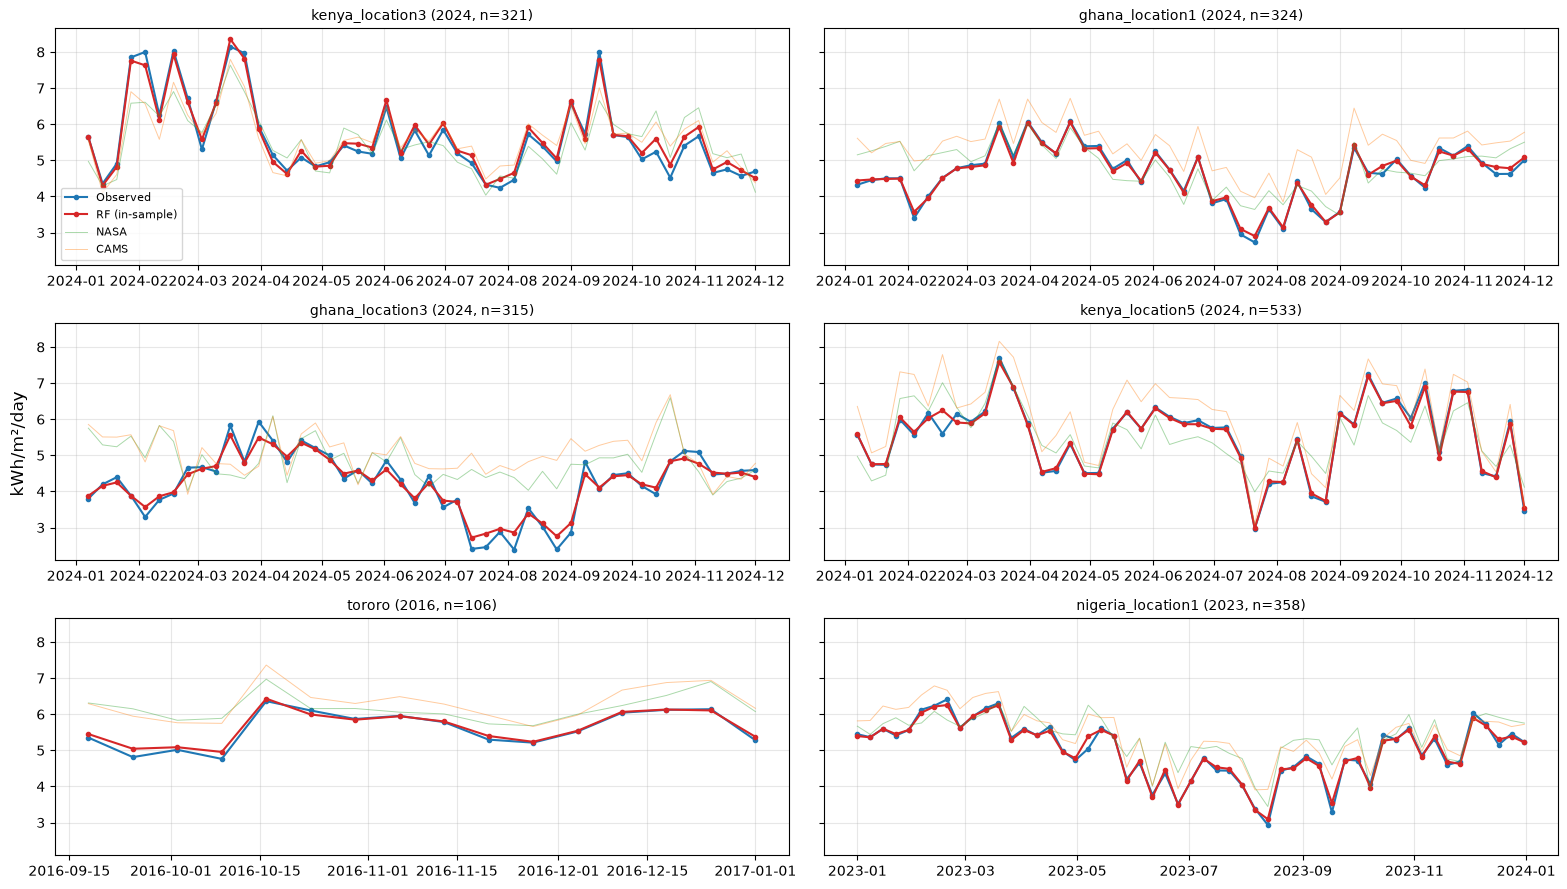

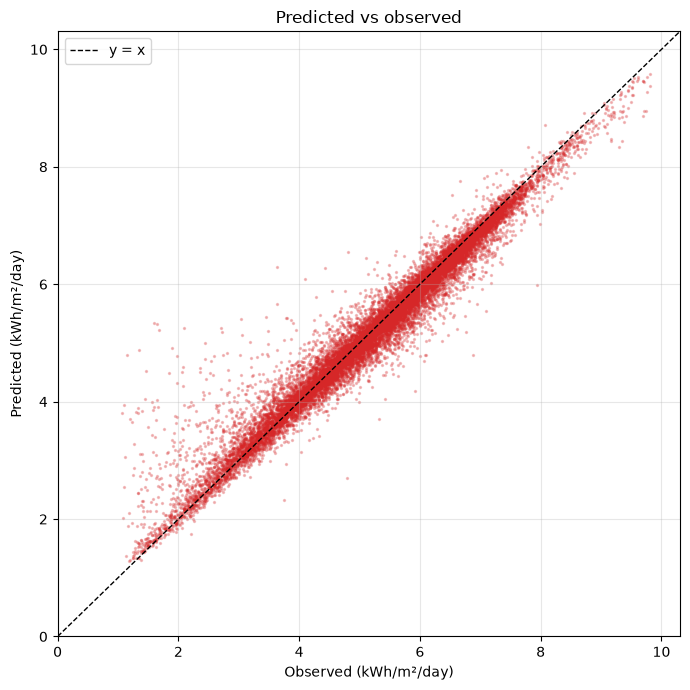

RMSE = 0.308  MAE = 0.190  MBE = -0.009


In [13]:
diag_df = processed.df.copy()
diag_df["y_pred"] = bundle.regressor.predict(processed.X())
diag_df["date"] = pd.to_datetime(diag_df["date"])
from susse.evaluation.plots import (
    plot_training_fit_scatter, plot_training_fit_timeseries,
)

plot_training_fit_timeseries(
    diag_df,
    observed_column=spec.target_column,
    prediction_series={"RF (in-sample)": "y_pred"},
    reference_series={
        "NASA": "sat_ghi_nasa_kwh_m2_day",
        "CAMS": "sat_ghi_cams_kwh_m2_day",
    },
)
plot_training_fit_scatter(
    diag_df,
    observed_column=spec.target_column,
    predicted_column="y_pred",
)

## 6 — Validate against the Katongole 54-station network

The paper's primary validation compares a 6-year climatology of model
predictions (2015–2022) against the published Katongole et al. monthly
GHI averages at the same 54 Ugandan coordinates. This is a fully
out-of-distribution test — a different country, different sensor
network, and different time window from the training data.

In [14]:
from susse.warehouse_ops.io.repositories import SatelliteRepository
import auxscripts

VAL_START = date(VALIDATION_START_YEAR, 1, 1)
VAL_END = date(VALIDATION_END_YEAR, 12, 31)

katongole = pd.read_csv(KATONGOLE_CSV)
katongole["geohash5"] = [
    pygeohash.encode(lat, lon, precision=5)
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]

# Train-fold geohashes and NASA 0.5° cells — overlap flags for §6 metrics.
train_fold = processed.df.loc[train_idx]
training_geohashes = set(train_fold["geohash5"].unique())
training_nasa_cells = {
    (int(np.floor((lat + 90) / 0.5)), int(np.floor((lon + 180) / 0.5)))
    for lat, lon in zip(train_fold["lat"], train_fold["lon"])
}
katongole["nasa_cell"] = [
    (int(np.floor((lat + 90) / 0.5)), int(np.floor((lon + 180) / 0.5)))
    for lat, lon in zip(katongole["latitude"], katongole["longitude"])
]
katongole["seen_in_training_geohash5"] = katongole["geohash5"].isin(training_geohashes)
katongole["seen_in_training_nasa_cell"] = katongole["nasa_cell"].isin(training_nasa_cells)
print(
    f"{len(katongole)} Katongole stations:  "
    f"{int(katongole['seen_in_training_geohash5'].sum())} share a geohash5 "
    f"with a training station,  "
    f"{int(katongole['seen_in_training_nasa_cell'].sum())} share a NASA 0.5° cell."
)

# Hard-fail if any station lacks coverage. Pass allow_partial=True for
# inspecting intermediate state while the A12 ingest is still running.
auxscripts.assert_katongole_coverage(
    bq, tables, katongole, VAL_START, VAL_END,
)
inference_df = auxscripts.build_katongole_inference_frame(
    bq=bq, tables=tables, sat_repo=SatelliteRepository(bq=bq),
    katongole=katongole, selection=selection,
    nasa_aux_ids=NASA_AUX_VARIABLE_IDS, cams_aux_ids=CAMS_VARIABLE_IDS,
    val_start=VAL_START, val_end=VAL_END,
)
auxscripts.assert_inference_complete(katongole, inference_df)

56 Katongole stations:  3 share a geohash5 with a training station,  4 share a NASA 0.5° cell.


In [15]:
# Apply the trained bundle's feature spec to the inference frame and
# predict. Reloading from disk mirrors what the portal does.
from susse.training import load_bundle

restored = load_bundle(
    BUNDLE_DEST, providers={"altitude": PvlibElevationProvider()},
)
inference_dataset = TrainingDataset(
    df=inference_df.assign(y_ghi_kwh_m2_day=np.nan),
    manifest=manifest,
)
inference_spec_for_predict = FeatureSpec(
    target_column=restored.feature_spec.target_column,
    feature_columns=restored.feature_spec.feature_columns,
    cleaners=(),
    derived_features=restored.feature_spec.derived_features,
    id_columns=restored.feature_spec.id_columns,
    dropna_target=False, dropna_features=False,
)
inference_processed = Preprocessor(inference_spec_for_predict).apply(inference_dataset)
inference_processed.df["y_pred_kwh_m2_day"] = restored.regressor.predict(
    inference_processed.X()
)
print(
    f"Predictions: {len(inference_processed.df):,} daily values across "
    f"{inference_processed.df['location'].nunique()} stations"
)

Predictions: 122,696 daily values across 56 stations


In [16]:
# Aggregate daily predictions to a monthly climatology per station,
# then join with the Katongole reference values for scoring.
monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])["y_pred_kwh_m2_day"]
    .mean().reset_index()
    .rename(columns={"y_pred_kwh_m2_day": "monthly_pred"})
)
sat_monthly = (
    inference_processed.df
    .assign(month=lambda d: pd.to_datetime(d["date"]).dt.month)
    .groupby(["location", "month"])[
        ["sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day"]
    ].mean().reset_index()
)
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
katongole_long = katongole.melt(
    id_vars=["location", "latitude", "longitude", "altitude",
             "geohash5", "seen_in_training_geohash5", "seen_in_training_nasa_cell"],
    value_vars=month_names,
    var_name="month_name", value_name="monthly_obs",
)
katongole_long["month"] = katongole_long["month_name"].apply(
    lambda m: month_names.index(m) + 1
)
comparison = (
    monthly
    .merge(katongole_long, on=["location", "month"], how="inner")
    .merge(sat_monthly,    on=["location", "month"], how="left")
)
table_iv_raw = pd.concat([
    auxscripts.score_table_iv(comparison, label=f"all {comparison['location'].nunique()} stations"),
    auxscripts.score_table_iv(
        comparison[~comparison["seen_in_training_geohash5"]],
        label="excluding training-geohash overlaps",
    ),
])
print("=== Paper Table IV equivalent (uncalibrated) ===")
print(table_iv_raw.to_string(index=False))

=== Paper Table IV equivalent (uncalibrated) ===
                              split      model   n  RMSE  nRMSE_%   MAE  nMAE_%   MBE     R²   IOA
                    all 56 stations         RF 672 0.885    20.73 0.758   17.75 0.730 -1.180 0.564
                    all 56 stations NASA CERES 672 1.249    29.26 1.130   26.46 1.115 -3.344 0.462
                    all 56 stations       CAMS 672 1.338    31.34 1.239   29.03 1.231 -3.984 0.460
excluding training-geohash overlaps         RF 636 0.871    20.47 0.746   17.54 0.717 -1.270 0.550
excluding training-geohash overlaps NASA CERES 636 1.229    28.89 1.115   26.20 1.099 -3.521 0.453
excluding training-geohash overlaps       CAMS 636 1.308    30.74 1.218   28.64 1.210 -4.118 0.455


## 6.3 — Sensor-network calibration at Makerere

The paper's validation applies a calibration correction to account for a
known systematic offset between sensor networks. The Katongole dataset
uses TAHMO ATMOS 41 combination sensors, while the training data uses
MEMD/CrossBoundary research-grade pyranometers. The `kampala` training
station and the Katongole `Makerere S` station occupy identical
coordinates `(0.333542°, 32.56863°)`, allowing a direct measurement of
this network offset over the 2017–2022 overlap window.

Annual mean ratio (kampala / Makerere S): 1.180


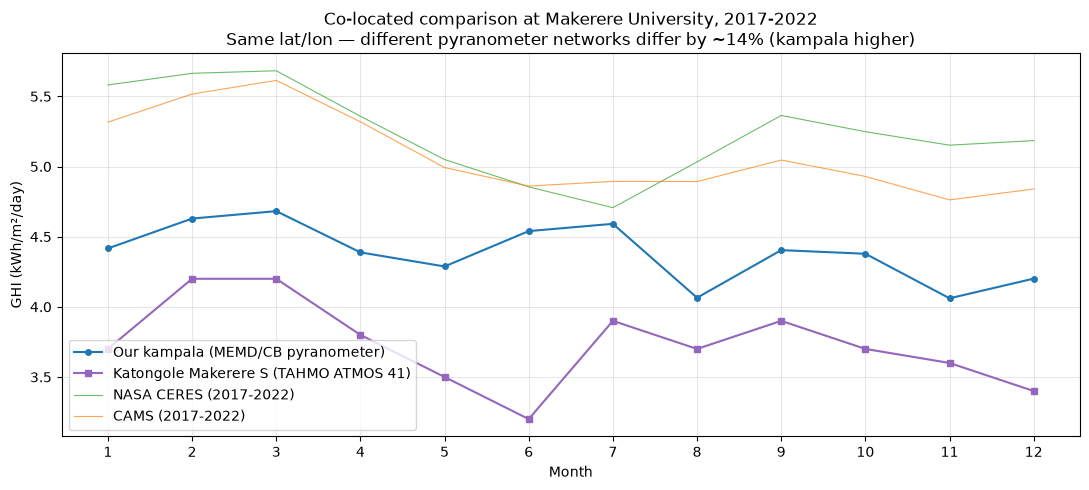

In [17]:
# Pull our kampala monthly climatology over 2017-2022.
kampala_monthly = bq.query(f"""
SELECT EXTRACT(MONTH FROM date) AS month,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS kampala_mean,
       COUNT(*) AS n_days
FROM `{tables.ground_measurements}`
WHERE location = "kampala" AND qc_level = "pass"
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month ORDER BY month
""")
makerere_row = katongole[katongole["location"] == "Makerere S"]
makerere_long = pd.DataFrame({
    "month": list(range(1, 13)),
    "makerere_mean": [float(makerere_row[m].iloc[0]) for m in month_names],
})
kampala_gh = pygeohash.encode(0.333542, 32.56863, 5)
sat_monthly_2017_22 = bq.query(f"""
SELECT EXTRACT(MONTH FROM date) AS month, source,
       ROUND(AVG(ghi_kwh_m2_day), 4) AS mean_ghi
FROM `{tables.irradiance_daily}`
WHERE geohash5 = "{kampala_gh}"
  AND source IN ("NASA", "CAMS")
  AND date BETWEEN DATE("2017-01-01") AND DATE("2022-12-31")
GROUP BY month, source ORDER BY month, source
""").pivot(index="month", columns="source", values="mean_ghi").reset_index()

calibration_df = (
    kampala_monthly.merge(makerere_long, on="month")
    .merge(sat_monthly_2017_22, on="month")
)
calibration_df["ratio"] = (
    calibration_df["kampala_mean"] / calibration_df["makerere_mean"]
)
annual_ratio = float(calibration_df["ratio"].mean())
print(f"Annual mean ratio (kampala / Makerere S): {annual_ratio:.3f}")
auxscripts.plot_calibration_discrepancy(calibration_df)

## 6.4 — Calibrated Table IV (paper result)

A single annual calibration ratio (mean of 12 monthly ratios, ~1.18)
rescales the Katongole reference values onto the MEMD/CB sensor scale
before scoring. Per-month ratios are not used — fitting them on one
co-located pair over 7 years would overfit (June's ~1.42 ratio
produces non-physical corrected values at some sites). A monotonic
linear rescaling shifts RF and satellite errors together, so the
relative improvement claim is preserved. The geohash-overlap exclusion
(one validation station shares a geohash5 cell with a training station)
gives the paper's primary result of 53 geographically independent sites.

In [22]:
comparison_calibrated = comparison.copy()
comparison_calibrated["monthly_obs_calibrated"] = (
    comparison_calibrated["monthly_obs"] * annual_ratio
)
table_iv_calibrated = pd.concat([
    auxscripts.score_table_iv(
        comparison_calibrated,
        label=f"all {comparison_calibrated['location'].nunique()} stations",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
    auxscripts.score_table_iv(
        comparison_calibrated[~comparison_calibrated["seen_in_training_geohash5"]],
        label="excluding training-geohash overlaps",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
    auxscripts.score_table_iv(
        comparison_calibrated[~comparison_calibrated["seen_in_training_nasa_cell"]],
        label="excluding training-NASA-cell overlaps",
        obs_col="monthly_obs_calibrated",
        rf_label="RF (calibrated)",
    ),
])
print("=== Paper Table IV equivalent — calibration-corrected ===")
print(table_iv_calibrated.to_string(index=False))

=== Paper Table IV equivalent — calibration-corrected ===
                                split           model   n  RMSE  nRMSE_%   MAE  nMAE_%    MBE     R²   IOA
                      all 56 stations RF (calibrated) 672 0.587    11.66 0.424    8.42 -0.039  0.310 0.677
                      all 56 stations      NASA CERES 672 0.732    14.53 0.526   10.45  0.346 -0.072 0.608
                      all 56 stations            CAMS 672 0.758    15.05 0.558   11.08  0.462 -0.150 0.637
  excluding training-geohash overlaps RF (calibrated) 636 0.582    11.58 0.420    8.36 -0.050  0.273 0.653
  excluding training-geohash overlaps      NASA CERES 636 0.713    14.20 0.515   10.25  0.333 -0.092 0.597
  excluding training-geohash overlaps            CAMS 636 0.725    14.43 0.542   10.80  0.444 -0.128 0.639
excluding training-NASA-cell overlaps RF (calibrated) 624 0.581    11.57 0.417    8.30 -0.051  0.276 0.654
excluding training-NASA-cell overlaps      NASA CERES 624 0.708    14.11 0.511   10.19

### Residual diagnostics

Three diagnostic views on the §6.4 metrics: covariate-shift KDEs
(training vs Katongole feature distributions), a predicted-vs-observed
scatter, and per-station MBE.

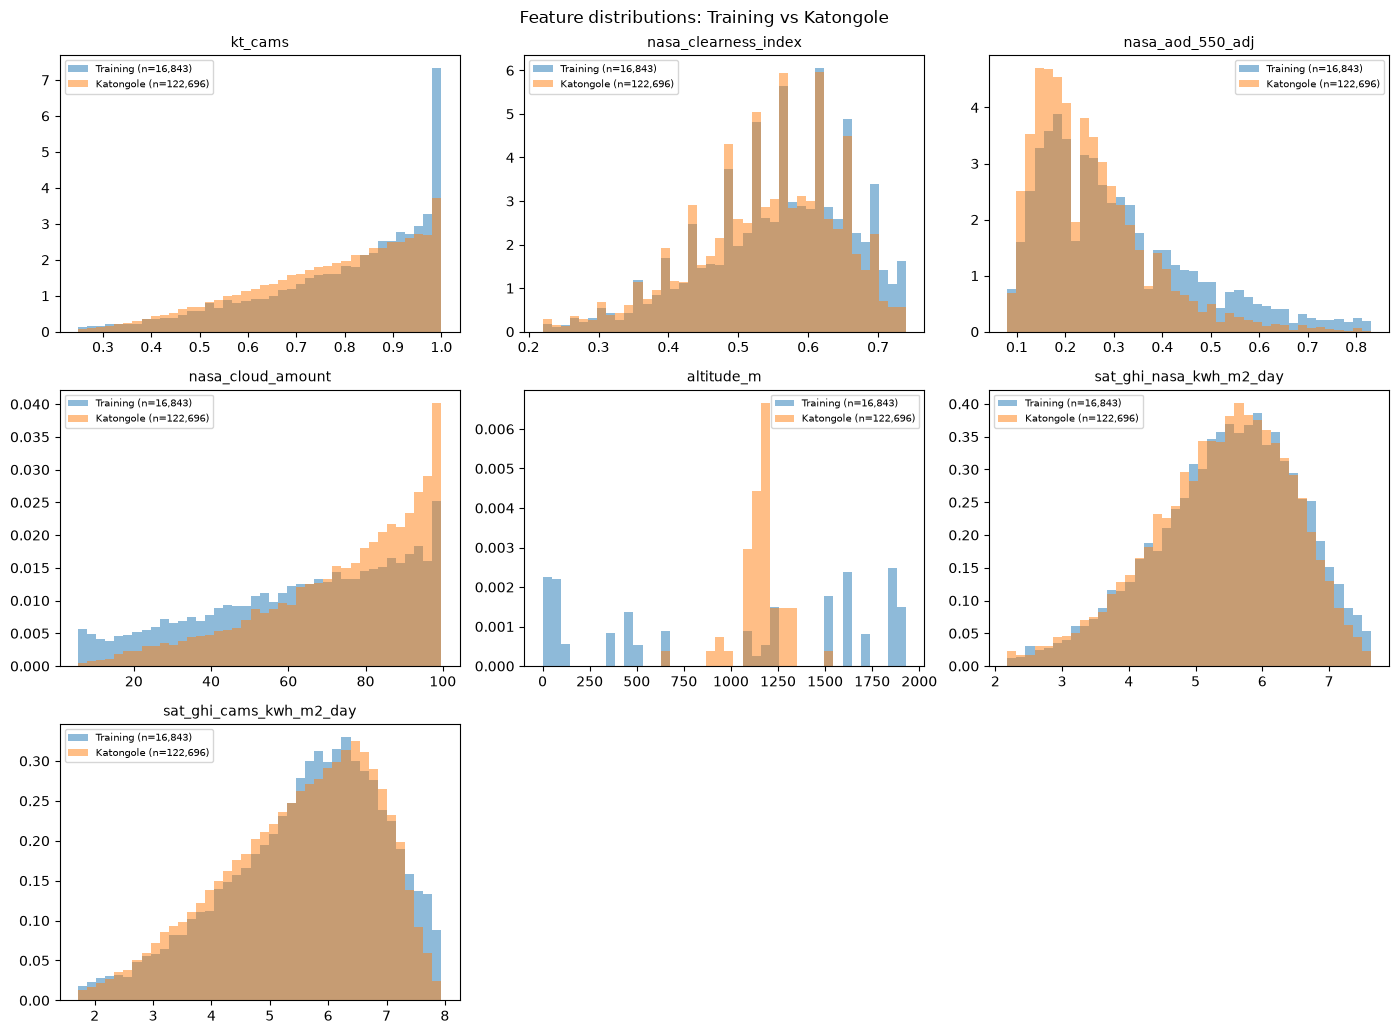

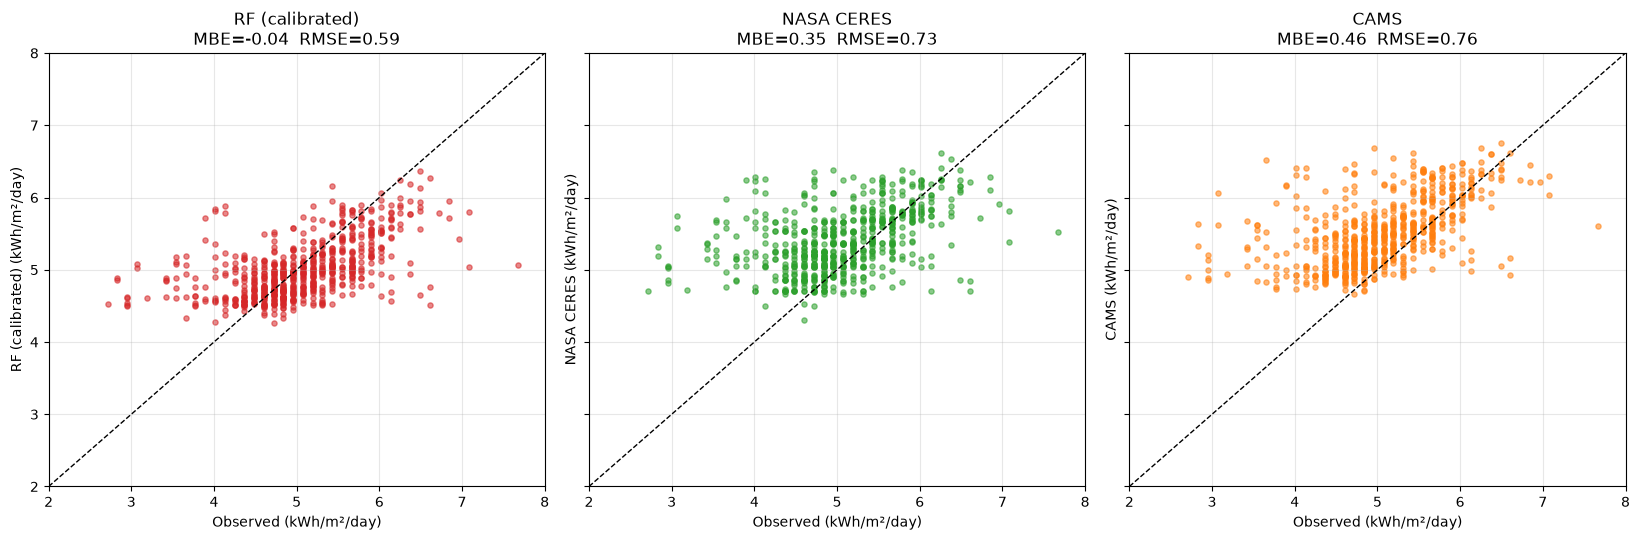

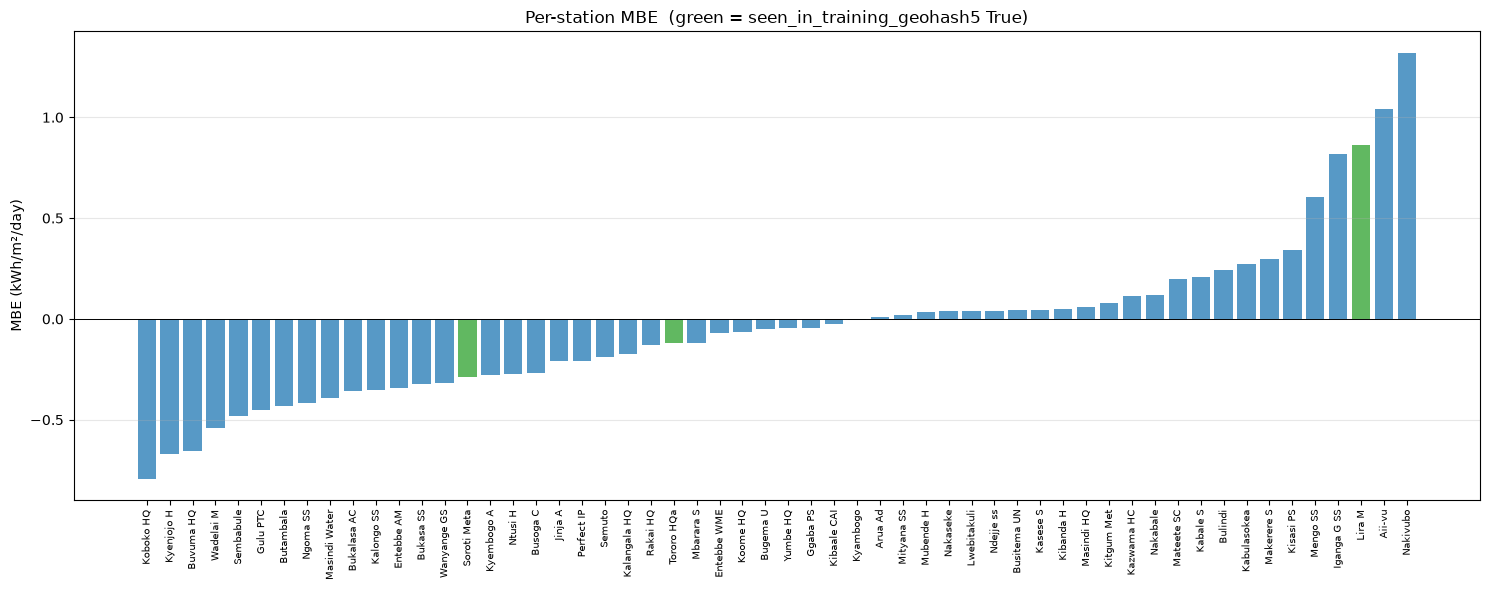

Worst (highest MBE):
               MBE  _highlight
location                      
Mengo SS     0.604       False
Iganga G SS  0.816       False
Lira M       0.861        True
Aii-vu       1.040       False
Nakivubo     1.321       False

Best (lowest MBE):
              MBE  _highlight
location                     
Koboko HQ  -0.792       False
Kyenjojo H -0.671       False
Buvuma HQ  -0.656       False
Wadelai M  -0.540       False
Sembabule  -0.483       False


In [19]:
from susse.evaluation import MeanBiasError
from susse.evaluation.plots import (
    plot_covariate_shift_kde,
    plot_per_station_metric,
    plot_predicted_vs_observed_panels,
)

plot_covariate_shift_kde(
    processed.df, inference_processed.df,
    features=[
        "kt_cams", "nasa_clearness_index", "nasa_aod_550_adj",
        "nasa_cloud_amount", "altitude_m",
        "sat_ghi_nasa_kwh_m2_day", "sat_ghi_cams_kwh_m2_day",
    ],
    train_label="Training", val_label="Katongole",
)
plot_predicted_vs_observed_panels(
    comparison_calibrated,
    observed_column="monthly_obs_calibrated",
    predictions={
        "RF (calibrated)": "monthly_pred",
        "NASA CERES":      "sat_ghi_nasa_kwh_m2_day",
        "CAMS":            "sat_ghi_cams_kwh_m2_day",
    },
)
plot_per_station_metric(
    comparison_calibrated,
    observed_column="monthly_obs_calibrated",
    predicted_column="monthly_pred",
    metric=MeanBiasError(),
    highlight_column="seen_in_training_geohash5",
)

## 7 — Figures

* **Figure 2** — 4 × 4 grid of monthly GHI comparison panels for the
  16 paper stations across the four climatic regions (Northern, Eastern,
  Central, Western). Series per panel: measured/calibrated (blue), RF
  predicted (red), NASA CERES (green), CAMS (orange).
* **Figure 3** — top RF feature importances with paper-table variable
  names.

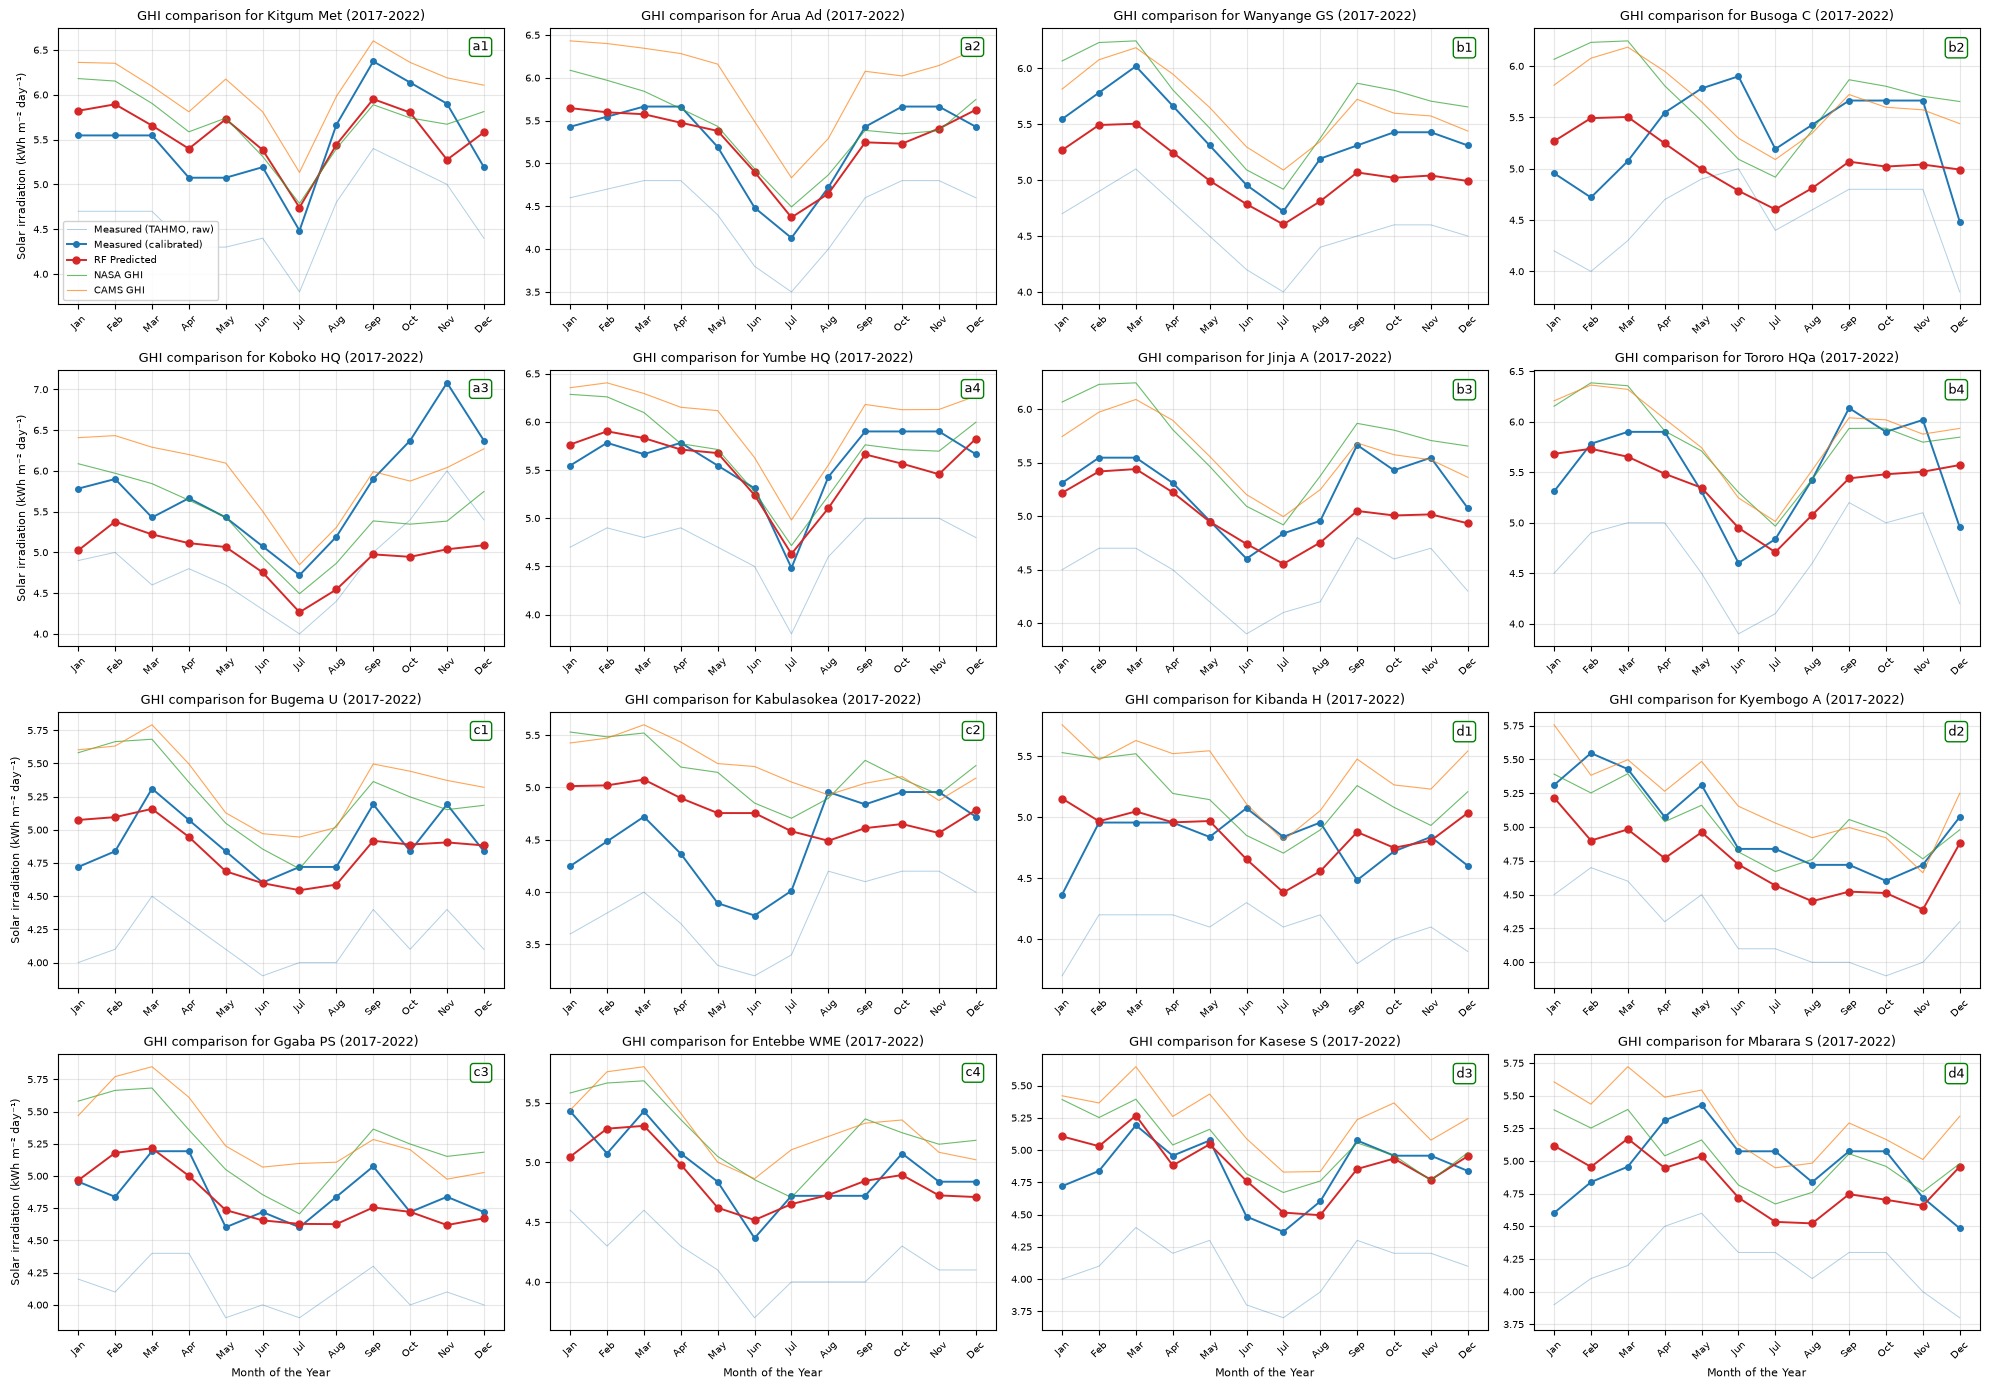

['Kitgum Met',
 'Arua Ad',
 'Wanyange GS',
 'Busoga C',
 'Koboko HQ',
 'Yumbe HQ',
 'Jinja A',
 'Tororo HQa',
 'Bugema U',
 'Kabulasokea',
 'Kibanda H',
 'Kyembogo A',
 'Ggaba PS',
 'Entebbe WME',
 'Kasese S',
 'Mbarara S']

In [20]:
# Paper Figure 2 — 16 stations pinned to match the paper exactly.
val_stations = [
    "Kitgum Met", "Arua Ad",    "Wanyange GS", "Busoga C",
    "Koboko HQ",  "Yumbe HQ",   "Jinja A",     "Tororo HQa",
    "Bugema U",   "Kabulasokea", "Kibanda H",   "Kyembogo A",
    "Ggaba PS",   "Entebbe WME", "Kasese S",    "Mbarara S",
]

auxscripts.plot_figure_2_grid(
    comparison_calibrated,
    validation_label=f"{VALIDATION_START_YEAR}-{VALIDATION_END_YEAR}",
    stations=val_stations,
    observed=True,
)

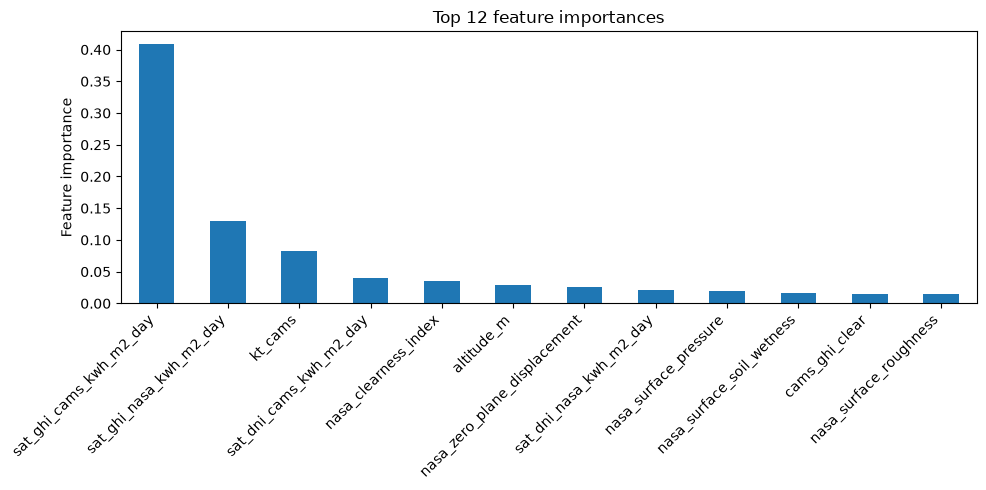

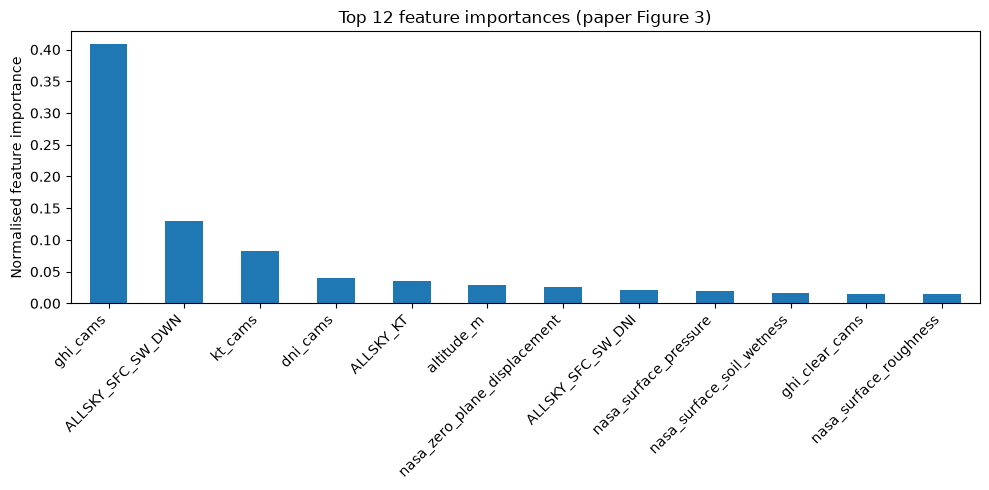

In [21]:
# Paper Figure 3 — feature importances with paper Table II variable names.
from susse.evaluation.plots import plot_feature_importances_top_n
import matplotlib.pyplot as plt

top_importances = plot_feature_importances_top_n(
    bundle, feature_columns=processed.feature_columns, top_n=12,
)

# Rename warehouse column IDs to the paper's Table II names.
top_importances = top_importances.rename(index={
    "sat_ghi_nasa_kwh_m2_day": "ALLSKY_SFC_SW_DWN",
    "sat_ghi_cams_kwh_m2_day": "ghi_cams",
    "kt_cams":                  "kt_cams",
    "nasa_clearness_index":     "ALLSKY_KT",
    "nasa_cloud_amount":        "CLOUD_AMT",
    "sat_dni_nasa_kwh_m2_day":  "ALLSKY_SFC_SW_DNI",
    "sat_dni_cams_kwh_m2_day":  "dni_cams",
    "cams_ghi_clear":           "ghi_clear_cams",
    "sat_dhi_cams_kwh_m2_day":  "dhi_cams",
    "cams_dhi_clear":           "dhi_clear_cams",
})

fig, ax = plt.subplots(figsize=(10, 5))
top_importances.plot.bar(ax=ax, color="#1f77b4")
ax.set_ylabel("Normalised feature importance")
ax.set_title("Top 12 feature importances (paper Figure 3)")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

## 8 — Bundle deliverable for Irradiation_Portal

The portal loads a `TrainedBundle` from a fixed directory. After this
notebook runs cleanly the directory at `BUNDLE_DEST` contains:

```
mukiibi_mikelson_2026/
├── model/
│   ├── model_kind.txt       # → "random_forest"
│   ├── params.json          # → {n_estimators: 200, min_samples_leaf: 5, …}
│   └── state.joblib         # the fitted sklearn estimator
├── feature_spec.json        # cleaners + derived features + pass-through cols
├── metadata.json            # train + val + baseline ScoreSet, splitter name, …
└── source_manifest.json     # warehouse-state snapshot used to build the dataset
```

The model predicts absolute GHI directly — `regressor.predict(X)`
returns the bias-corrected value, no inversion step needed.

```python
restored = load_bundle(
    bundle_dir, providers={"altitude": PvlibElevationProvider()},
)
y_pred = restored.regressor.predict(X)  # kWh/m²/day, ready to consume
```

The earlier `load_bundle` call in §6 already verified this round-trip,
so the on-disk bundle is portable to the portal as-is.

## 9 — Implementation notes

| Topic | Detail |
|---|---|
| **Sensor-network calibration** | The Katongole validation network (TAHMO ATMOS 41) reads ~14–18% lower than the MEMD/CrossBoundary training network at the co-located Makerere site. §6.3–6.4 derive and apply a single annual ratio (~1.18) to bring both networks onto the same scale before computing Table IV metrics. The relative improvement (RF vs satellites) is preserved under any monotonic rescaling. |
| **Geohash overlap exclusion** | One Katongole validation station shares a geohash5 cell with a training station. The paper's primary Table IV result excludes this station (53 sites), giving a fully geographically independent evaluation. The full 54-station uncalibrated result is also printed in §6 for reference. |
| **Holdout station identity** | Kampala (Site A) and Wadelai (Site B) are passed explicitly to `pick_training_and_holdout_stations` via `holdout_stations=`. The function validates that both names exist in the top-24 candidates by row count before accepting them. |
| **`kt_cams` definition** | Computed as `cams_ghi_clear / sat_ghi_cams` — the clear-sky attenuation ratio, not the conventional clearness index (GHI / extraterrestrial irradiance). See paper Table II. |
| **Day-of-year encoding** | Only the sin/cos cyclical pair is used (`doy_sin`, `doy_cos`). The raw integer `day_of_year` is excluded — it is information-equivalent but introduces a wrap-around discontinuity at the year boundary that decision trees handle less cleanly. |